In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
# Admission data
df = pd.read_csv('ADMISSIONS.csv.gz', compression='gzip')

# Patient specific info such as gender
df_pat = pd.read_csv('PATIENTS.csv.gz', compression='gzip')

# Diagnosis for each admission to hospital
df_diagcode = pd.read_csv('DIAGNOSES_ICD.csv.gz', compression='gzip')

### Feature Engineering: ADMISSIONS Table

In [4]:
list(df)

['ROW_ID',
 'SUBJECT_ID',
 'HADM_ID',
 'ADMITTIME',
 'DISCHTIME',
 'DEATHTIME',
 'ADMISSION_TYPE',
 'ADMISSION_LOCATION',
 'DISCHARGE_LOCATION',
 'INSURANCE',
 'LANGUAGE',
 'RELIGION',
 'MARITAL_STATUS',
 'ETHNICITY',
 'EDREGTIME',
 'EDOUTTIME',
 'DIAGNOSIS',
 'HOSPITAL_EXPIRE_FLAG',
 'HAS_CHARTEVENTS_DATA']

In [5]:
# get counts of patients died in the hospital
df["HOSPITAL_EXPIRE_FLAG"].value_counts()

HOSPITAL_EXPIRE_FLAG
0    53122
1     5854
Name: count, dtype: int64

In [6]:
# Convert admission and discharge to datatime type
df['ADMITTIME'] = pd.to_datetime(df['ADMITTIME'])
df['DISCHTIME'] = pd.to_datetime(df['DISCHTIME'])

# Convert timedelta type into float 'days', 86400 seconds in a day
df['LOS'] = (df['DISCHTIME'] - df['ADMITTIME']).dt.total_seconds()/86400

# Drop rows with negative LOS, usually related to a time of death before admission
df = df[df['LOS'] > 0]

df["HOSPITAL_EXPIRE_FLAG"].value_counts()

HOSPITAL_EXPIRE_FLAG
0    53104
1     5774
Name: count, dtype: int64

In [7]:
df.head()

,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA,LOS
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2196-04-09 10:06:00,2196-04-09 13:24:00,BENZODIAZEPINE OVERDOSE,0,1,1.144444
1,22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,NaN,NaN,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0,1,5.496528
2,23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,NaN,NaN,BRAIN MASS,0,1,6.768056
3,24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,NaN,NaN,INTERIOR MYOCARDIAL INFARCTION,0,1,2.856944
4,25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2160-11-02 01:01:00,2160-11-02 04:27:00,ACUTE CORONARY SYNDROME,0,1,3.534028


In [8]:
df['ETHNICITY'].value_counts()

ETHNICITY
WHITE                                                       40939
BLACK/AFRICAN AMERICAN                                       5434
UNKNOWN/NOT SPECIFIED                                        4502
HISPANIC OR LATINO                                           1693
ASIAN                                                        1508
OTHER                                                        1507
UNABLE TO OBTAIN                                              809
PATIENT DECLINED TO ANSWER                                    559
ASIAN - CHINESE                                               277
HISPANIC/LATINO - PUERTO RICAN                                232
BLACK/CAPE VERDEAN                                            200
WHITE - RUSSIAN                                               164
MULTI RACE ETHNICITY                                          130
BLACK/HAITIAN                                                 101
ASIAN - ASIAN INDIAN                                           85


In [9]:
nan_counts_by_column = df.isna().sum()
print(nan_counts_by_column)

ROW_ID                      0
SUBJECT_ID                  0
HADM_ID                     0
ADMITTIME                   0
DISCHTIME                   0
DEATHTIME               53104
ADMISSION_TYPE              0
ADMISSION_LOCATION          0
DISCHARGE_LOCATION          0
INSURANCE                   0
LANGUAGE                25272
RELIGION                  452
MARITAL_STATUS          10097
ETHNICITY                   0
EDREGTIME               28057
EDOUTTIME               28057
DIAGNOSIS                  25
HOSPITAL_EXPIRE_FLAG        0
HAS_CHARTEVENTS_DATA        0
LOS                         0
dtype: int64


In [10]:
# Compress the number of ethnicity categories
df['ETHNICITY'].replace(regex=r'^ASIAN\D*', value='ASIAN', inplace=True)
df['ETHNICITY'].replace(regex=r'^WHITE\D*', value='WHITE', inplace=True)
df['ETHNICITY'].replace(regex=r'^HISPANIC\D*', value='HISPANIC/LATINO', inplace=True)
df['ETHNICITY'].replace(regex=r'^BLACK\D*', value='BLACK/AFRICAN AMERICAN', inplace=True)
df['ETHNICITY'].replace(['UNABLE TO OBTAIN', 'OTHER', 'PATIENT DECLINED TO ANSWER',
                         'UNKNOWN/NOT SPECIFIED'], value='OTHER/UNKNOWN', inplace=True)
df['ETHNICITY'].loc[~df['ETHNICITY'].isin(df['ETHNICITY'].value_counts().nlargest(5).index.tolist())] = 'OTHER/UNKNOWN'
df['ETHNICITY'].value_counts()

C:\Users\yherw\AppData\Local\Temp\ipykernel_36340\1325925633.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ETHNICITY'].replace(regex=r'^ASIAN\D*', value='ASIAN', inplace=True)
C:\Users\yherw\AppData\Local\Temp\ipykernel_36340\1325925633.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

ETHNICITY
WHITE                     41268
OTHER/UNKNOWN              7700
BLACK/AFRICAN AMERICAN     5779
HISPANIC/LATINO            2125
ASIAN                      2006
Name: count, dtype: int64

In [11]:
df['RELIGION'].value_counts()

RELIGION
CATHOLIC                  20580
NOT SPECIFIED             11738
UNOBTAINABLE               8242
PROTESTANT QUAKER          7121
JEWISH                     5307
OTHER                      2695
EPISCOPALIAN                771
GREEK ORTHODOX              459
CHRISTIAN SCIENTIST         429
BUDDHIST                    267
MUSLIM                      225
JEHOVAH'S WITNESS           139
UNITARIAN-UNIVERSALIST      124
HINDU                       113
ROMANIAN EAST. ORTH          83
7TH DAY ADVENTIST            81
BAPTIST                      28
HEBREW                       16
METHODIST                     7
LUTHERAN                      1
Name: count, dtype: int64

In [12]:
df['ADMISSION_TYPE'].value_counts()

ADMISSION_TYPE
EMERGENCY    41989
NEWBORN       7854
ELECTIVE      7702
URGENT        1333
Name: count, dtype: int64

In [13]:
df['INSURANCE'].value_counts()

INSURANCE
Medicare      28174
Private       22542
Medicaid       5778
Government     1781
Self Pay        603
Name: count, dtype: int64

In [14]:
# Ethnicity has to many other/unknown category therefore might not be useful for analysis
# Religion has many NOT SPECIFIED and UNOBTAINABLE, therefore might not be useful for analysis
# Marital status has many empty values
# Language has many empty values as well
# drop columns that is not needed for analysis
df.drop(columns=['DISCHTIME', 'ROW_ID', 'ADMISSION_LOCATION', 'DISCHARGE_LOCATION','DIAGNOSIS','DEATHTIME',
                'EDREGTIME', 'EDOUTTIME', 'ETHNICITY', 'RELIGION', 'MARITAL_STATUS', 'LANGUAGE', 'LOS',
                'HAS_CHARTEVENTS_DATA'], inplace=True)

In [15]:
df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG
0,22,165315,2196-04-09 12:26:00,EMERGENCY,Private,0
1,23,152223,2153-09-03 07:15:00,ELECTIVE,Medicare,0
2,23,124321,2157-10-18 19:34:00,EMERGENCY,Medicare,0
3,24,161859,2139-06-06 16:14:00,EMERGENCY,Private,0
4,25,129635,2160-11-02 02:06:00,EMERGENCY,Private,0


### Feature Engineering: DIAGNOSES_ICD Table

In [16]:
df_diagcode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651047 entries, 0 to 651046
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ROW_ID      651047 non-null  int64  
 1   SUBJECT_ID  651047 non-null  int64  
 2   HADM_ID     651047 non-null  int64  
 3   SEQ_NUM     651000 non-null  float64
 4   ICD9_CODE   651000 non-null  object 
dtypes: float64(1), int64(3), object(1)
memory usage: 24.8+ MB


In [17]:
print('There are {} unique ICD9 codes in this dataset.'.format(df_diagcode['ICD9_CODE'].value_counts().count()))

There are 6984 unique ICD9 codes in this dataset.


In [19]:
diag_nan_counts_by_column = df_diagcode.isna().sum()
print(diag_nan_counts_by_column)

ROW_ID         0
SUBJECT_ID     0
HADM_ID        0
SEQ_NUM       47
ICD9_CODE     47
dtype: int64


In [20]:
# Filter out E and V codes since processing will be done on the numeric first 3 values
df_diagcode['recode'] = df_diagcode['ICD9_CODE']
df_diagcode['recode'] = df_diagcode['recode'][~df_diagcode['recode'].str.contains("[a-zA-Z]").fillna(False)]
df_diagcode['recode'].fillna(value='999', inplace=True)

C:\Users\yherw\AppData\Local\Temp\ipykernel_36340\534943549.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_diagcode['recode'] = df_diagcode['recode'][~df_diagcode['recode'].str.contains("[a-zA-Z]").fillna(False)]
C:\Users\yherw\AppData\Local\Temp\ipykernel_36340\534943549.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the 

In [22]:
# https://stackoverflow.com/questions/46168450/replace-specific-range-of-values-in-data-frame-pandas
df_diagcode['recode'] = df_diagcode['recode'].str.slice(start=0, stop=3, step=1)
df_diagcode['recode'] = df_diagcode['recode'].astype(int)
df_diagcode.head()

,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE,recode
0,1297,109,172335,1.0,40301,403
1,1298,109,172335,2.0,486,486
2,1299,109,172335,3.0,58281,582
3,1300,109,172335,4.0,5855,585
4,1301,109,172335,5.0,4254,425


In [23]:
# ICD-9 Main Category ranges
icd9_ranges = [(1, 140), (140, 240), (240, 280), (280, 290), 
               (290, 320), (320, 390),(390, 460), (460, 520), 
               (520, 580), (580, 630), (630, 680), (680, 710),
               (710, 740), (740, 760), (760, 780), (780, 800), 
               (800, 1000), (1000, 2000)]

# Associated category names
diag_dict = {0: 'infectious', 1: 'neoplasms', 2: 'endocrine', 3: 'blood',
             4: 'mental', 5: 'nervous', 6: 'circulatory', 7: 'respiratory',
             8: 'digestive', 9: 'genitourinary', 10: 'pregnancy', 11: 'skin',
             12: 'muscular', 13: 'congenital', 14: 'prenatal', 15: 'symptoms',
             16: 'injury', 17: 'misc'}

# Re-code in terms of integer
for num, cat_range in enumerate(icd9_ranges):
    df_diagcode['recode'] = np.where(df_diagcode['recode'].between(cat_range[0], cat_range[1]),
                                     num, df_diagcode['recode'])

# Convert integer to category name using diag_dict
df_diagcode['recode'] = df_diagcode['recode']
df_diagcode['cat'] = df_diagcode['recode'].replace(diag_dict)

# Verify
print(df_diagcode.head())

   ROW_ID  SUBJECT_ID  HADM_ID  SEQ_NUM ICD9_CODE  recode            cat
0    1297         109   172335      1.0     40301       6    circulatory
1    1298         109   172335      2.0       486       7    respiratory
2    1299         109   172335      3.0     58281       9  genitourinary
3    1300         109   172335      4.0      5855       9  genitourinary
4    1301         109   172335      5.0      4254       6    circulatory


In [24]:
# Create list of diagnoses for each admission
hadm_list = df_diagcode.groupby('HADM_ID')['cat'].apply(list).reset_index()
hadm_list.head()

,HADM_ID,cat
0,100001,"[endocrine, nervous, genitourinary, digestive,..."
1,100003,"[digestive, blood, infectious, digestive, circ..."
2,100006,"[respiratory, respiratory, respiratory, neopla..."
3,100007,"[digestive, digestive, injury, respiratory, ci..."
4,100009,"[circulatory, injury, circulatory, endocrine, ..."


In [25]:
# Convert diagnoses list into hospital admission-item matrix
hadm_item = pd.get_dummies(hadm_list['cat'].apply(pd.Series).stack()).groupby(level=0).sum()
hadm_item.head()

,blood,circulatory,congenital,digestive,endocrine,genitourinary,infectious,injury,mental,muscular,neoplasms,nervous,pregnancy,prenatal,respiratory,skin,symptoms
0,0,2,0,2,5,2,0,2,0,0,0,2,0,0,0,1,0
1,1,2,0,4,0,0,1,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,1,0,0,2,1,0,1,0,0,0,3,0,1
3,0,1,0,2,0,0,0,1,0,0,0,0,0,0,1,0,0
4,1,7,0,0,3,0,0,7,0,0,0,0,0,0,0,0,0


In [26]:
# Join back with HADM_ID, will merge with main admissions DF later
hadm_item = hadm_item.join(hadm_list['HADM_ID'], how="outer")
hadm_item.head()

,blood,circulatory,congenital,digestive,endocrine,genitourinary,infectious,injury,mental,muscular,neoplasms,nervous,pregnancy,prenatal,respiratory,skin,symptoms,HADM_ID
0,0,2,0,2,5,2,0,2,0,0,0,2,0,0,0,1,0,100001
1,1,2,0,4,0,0,1,0,0,0,0,0,0,0,0,0,1,100003
2,0,0,0,0,1,0,0,2,1,0,1,0,0,0,3,0,1,100006
3,0,1,0,2,0,0,0,1,0,0,0,0,0,0,1,0,0,100007
4,1,7,0,0,3,0,0,7,0,0,0,0,0,0,0,0,0,100009


In [27]:
# Merge with main admissions df
df = df.merge(hadm_item, how='inner', on='HADM_ID')

# Verify Merge
df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,blood,circulatory,congenital,digestive,...,injury,mental,muscular,neoplasms,nervous,pregnancy,prenatal,respiratory,skin,symptoms
0,22,165315,2196-04-09 12:26:00,EMERGENCY,Private,0,0,1,0,0,...,4,1,0,0,1,0,0,0,0,0
1,23,152223,2153-09-03 07:15:00,ELECTIVE,Medicare,0,0,4,0,0,...,1,0,0,0,1,0,0,0,0,0
2,23,124321,2157-10-18 19:34:00,EMERGENCY,Medicare,0,0,2,0,0,...,3,0,0,1,1,0,1,0,0,0
3,24,161859,2139-06-06 16:14:00,EMERGENCY,Private,0,0,2,0,1,...,0,0,0,0,0,0,0,0,0,0
4,25,129635,2160-11-02 02:06:00,EMERGENCY,Private,0,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0


### Feature Engineering: Patients Table

In [28]:
df_pat.head()

,ROW_ID,SUBJECT_ID,GENDER,DOB,DOD,DOD_HOSP,DOD_SSN,EXPIRE_FLAG
0,234,249,F,2075-03-13 00:00:00,NaN,NaN,NaN,0
1,235,250,F,2164-12-27 00:00:00,2188-11-22 00:00:00,2188-11-22 00:00:00,NaN,1
2,236,251,M,2090-03-15 00:00:00,NaN,NaN,NaN,0
3,237,252,M,2078-03-06 00:00:00,NaN,NaN,NaN,0
4,238,253,F,2089-11-26 00:00:00,NaN,NaN,NaN,0


In [29]:
# Convert to datetime type
df_pat['DOB'] = pd.to_datetime(df_pat['DOB'])

df_pat = df_pat[['SUBJECT_ID', 'DOB', 'GENDER']]
df_pat.head()

,SUBJECT_ID,DOB,GENDER
0,249,2075-03-13,F
1,250,2164-12-27,F
2,251,2090-03-15,M
3,252,2078-03-06,M
4,253,2089-11-26,F


In [32]:
# Merge DOB and GENDER to the main dataframe
df = df.merge(df_pat, how='inner', on='SUBJECT_ID')

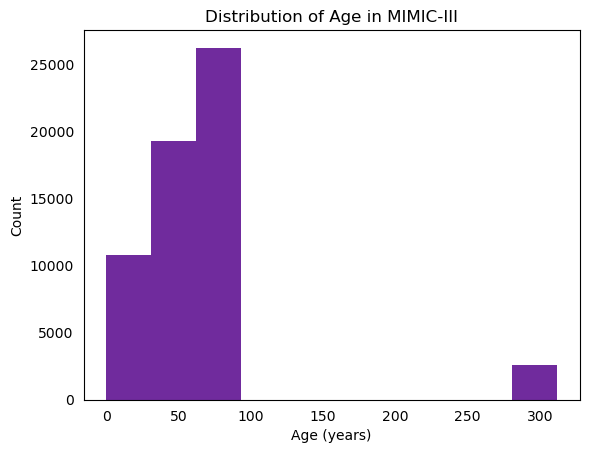

In [33]:
# Calculate age based on DOB and admission date
df['ADMIT_DATE'] = pd.to_datetime(df['ADMITTIME']).dt.date
df['DOB'] = pd.to_datetime(df['DOB']).dt.date
df['age'] = df.apply(lambda e: (e['ADMIT_DATE'] - e['DOB']).days/365, axis=1)

# Plot age distribution and check for outliers
plt.hist(df['age'], bins=10, color='#702b9d')
plt.ylabel('Count')
plt.xlabel('Age (years)')
plt.title('Distribution of Age in MIMIC-III')
plt.tick_params(left=False, bottom=False, top=False, right=False)
plt.show();

In [35]:
outlier_age = df[df['age']>200]
outlier_age.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,blood,circulatory,congenital,digestive,...,nervous,pregnancy,prenatal,respiratory,skin,symptoms,DOB,GENDER,ADMIT_DATE,age
8,30,104557,2172-10-14 14:17:00,URGENT,Medicare,0,0,6,0,0,...,0,0,0,0,0,0,1872-10-14,M,2172-10-14,300.200000
12,34,115799,2186-07-18 16:46:00,EMERGENCY,Medicare,0,0,6,0,0,...,0,0,0,0,0,0,1886-07-18,M,2186-07-18,300.200000
13,34,144319,2191-02-23 05:23:00,EMERGENCY,Medicare,0,0,5,0,0,...,1,0,0,0,0,0,1886-07-18,M,2191-02-23,304.805479
39,368,105889,2137-07-11 17:56:00,EMERGENCY,Medicare,0,0,2,0,1,...,0,0,0,2,0,0,1837-07-11,M,2137-07-11,300.200000
40,368,138061,2139-12-16 19:48:00,EMERGENCY,Medicare,0,0,6,0,1,...,0,0,0,3,0,0,1837-07-11,M,2139-12-16,302.632877


In [35]:
# remove records with age over 200 years
df = df[df['age'] < 200]
# change age as integer
df['age'] = df['age'].astype(int)
df['age'].describe()

count    56268.000000
mean        53.077326
std         26.639364
min          0.000000
25%         42.000000
50%         60.000000
75%         74.000000
max         89.000000
Name: age, dtype: float64

In [36]:
# Final distribution of patient survival in hospital
df["HOSPITAL_EXPIRE_FLAG"].value_counts()

HOSPITAL_EXPIRE_FLAG
0    51037
1     5231
Name: count, dtype: int64

In [41]:
df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,ADMISSION_TYPE,INSURANCE,HOSPITAL_EXPIRE_FLAG,blood,circulatory,congenital,digestive,...,nervous,pregnancy,prenatal,respiratory,skin,symptoms,DOB,GENDER,ADMIT_DATE,age
0,22,165315,2196-04-09 12:26:00,EMERGENCY,Private,0,0,1,0,0,...,1,0,0,0,0,0,2131-05-07,F,2196-04-09,64
1,23,152223,2153-09-03 07:15:00,ELECTIVE,Medicare,0,0,4,0,0,...,1,0,0,0,0,0,2082-07-17,M,2153-09-03,71
2,23,124321,2157-10-18 19:34:00,EMERGENCY,Medicare,0,0,2,0,0,...,1,0,1,0,0,0,2082-07-17,M,2157-10-18,75
3,24,161859,2139-06-06 16:14:00,EMERGENCY,Private,0,0,2,0,1,...,0,0,0,0,0,0,2100-05-31,M,2139-06-06,39
4,25,129635,2160-11-02 02:06:00,EMERGENCY,Private,0,0,3,0,0,...,0,0,0,0,0,0,2101-11-21,M,2160-11-02,58


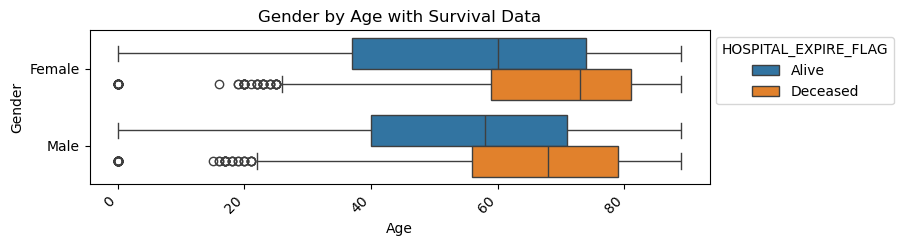

In [38]:
# Create box plot with age, gender and hospital survival
gender_ages = df[['age','GENDER','HOSPITAL_EXPIRE_FLAG']].copy()
gender_dict = { 'M':'Male', 'F':'Female'}
deceased_dict = { '0':'Alive', '1':'Deceased'}
gender_ages['GENDER'] = gender_ages['GENDER'].astype(str).replace(gender_dict)
gender_ages['HOSPITAL_EXPIRE_FLAG'] = gender_ages['HOSPITAL_EXPIRE_FLAG'].astype(str).replace(deceased_dict)

plt.figure(figsize=(8, 2))
ax = sns.boxplot(data=gender_ages, x='age', y='GENDER', hue='HOSPITAL_EXPIRE_FLAG',  orient='h')
plt.title("Gender by Age with Survival Data")
plt.xlabel("Age")
plt.ylabel("Gender")
plt.xticks(rotation=45, ha='right')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

# Show the plot
plt.show()

### Data Preprocessing

In [42]:
# Convert categorical variables into dummy/indicator variables
prefix_cols = ['ADM', 'INS', 'GENDER']
dummy_cols = ['ADMISSION_TYPE', 'INSURANCE', 'GENDER']
df_analysis = pd.get_dummies(df, prefix=prefix_cols, columns=dummy_cols)
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56268 entries, 0 to 58877
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   SUBJECT_ID            56268 non-null  int64         
 1   HADM_ID               56268 non-null  int64         
 2   ADMITTIME             56268 non-null  datetime64[ns]
 3   HOSPITAL_EXPIRE_FLAG  56268 non-null  int64         
 4   blood                 56268 non-null  int64         
 5   circulatory           56268 non-null  int64         
 6   congenital            56268 non-null  int64         
 7   digestive             56268 non-null  int64         
 8   endocrine             56268 non-null  int64         
 9   genitourinary         56268 non-null  int64         
 10  infectious            56268 non-null  int64         
 11  injury                56268 non-null  int64         
 12  mental                56268 non-null  int64         
 13  muscular             

In [44]:
# Target variable is HOSPITAL_EXPIRE_FLAG
DECEASED = df_analysis['HOSPITAL_EXPIRE_FLAG'].values
# Prediction Features
features = df_analysis.drop(columns=['SUBJECT_ID', 'HADM_ID', 'ADMITTIME',
                'HOSPITAL_EXPIRE_FLAG', 'DOB',
                'ADMIT_DATE'])

# Split into train 80% and test 20%
X_train, X_test, y_train, y_test = train_test_split(features,
                                                    DECEASED,
                                                    test_size = .20,
                                                    random_state = 0)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 45014 samples.
Testing set has 11254 samples.


In [45]:
# Data imbalance, only 10.2% (5231) is deceased in the hospital, use undersampling to balance the training data
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)
print("Resampled Training set has {} samples.".format(X_train_resampled.shape[0]))

Resampled Training set has 8460 samples.


In [46]:
np.sum(y_train_resampled)

4230

### Machine Learning Models

In [47]:
# Classifier models for comparison
models = [RandomForestClassifier(random_state = 0),
          GradientBoostingClassifier(random_state = 0),
          LogisticRegression(random_state = 0),
          KNeighborsClassifier(),
          DecisionTreeClassifier()]

results = {}

for model in models:
    # Instantiate and fit Regressor Model
    cls_model = model
    cls_model.fit(X_train_resampled, y_train_resampled)

    # Make predictions with model
    y_test_preds = cls_model.predict(X_test)
    error_rate = np.mean(y_test_preds != y_test)

    # Grab model name and store results associated with model
    name = str(model).split("(")[0]

    results[name] = error_rate
    print('{} done.'.format(name))

RandomForestClassifier done.
GradientBoostingClassifier done.
LogisticRegression done.


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KNeighborsClassifier done.
DecisionTreeClassifier done.


Text(0.5, 1.0, 'Comparison of Classification Models')

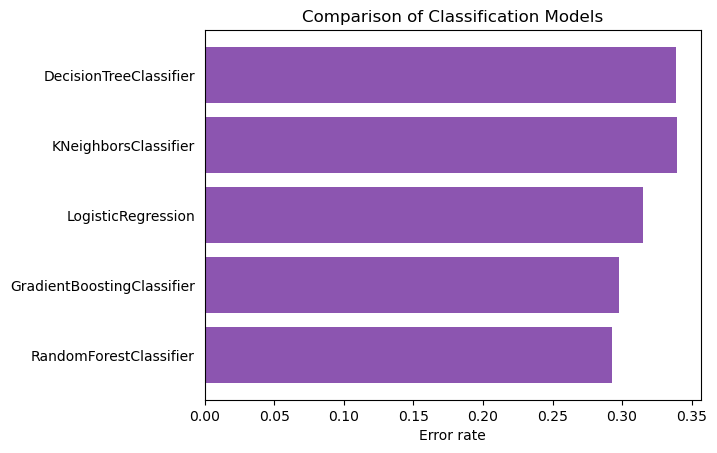

In [48]:
# error rate results, lowest error rate is the best algorithm
fig, ax = plt.subplots()
ind = range(len(results))
ax.barh(ind, list(results.values()), align='center',
        color = '#702b9d', alpha=0.8)
ax.set_yticks(ind)
ax.set_yticklabels(results.keys())
ax.set_xlabel('Error rate')
ax.tick_params(left=False, top=False, right=False)
ax.set_title('Comparison of Classification Models')

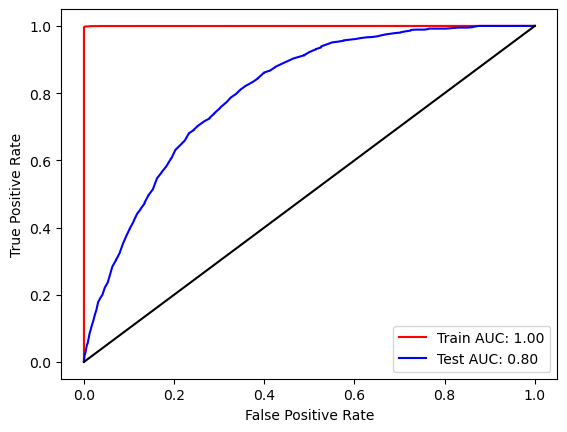

In [50]:
# RandomForestClassifier will be used as the hospital-death prediction model
rf_model = RandomForestClassifier()
rf_model.fit(X_train_resampled, y_train_resampled)

y_train_preds = rf_model.predict_proba(X_train_resampled)[:,1]
y_test_preds = rf_model.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr_train, tpr_train, thresholds_train = roc_curve(y_train_resampled, y_train_preds)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_preds)

auc_train = roc_auc_score(y_train_resampled, y_train_preds)
auc_test = roc_auc_score(y_test, y_test_preds)

plt.plot(fpr_train, tpr_train,'r-', label = 'Train AUC: %.2f'%auc_train)
plt.plot(fpr_test, tpr_test,'b-',label = 'Test AUC: %.2f'%auc_test)
plt.plot([0,1],[0,1],'-k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Model Finetuning

In [51]:
# Set the parameters by cross-validation
tuned_parameters = [{'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800],
                     'criterion': ['gini', 'entropy']}]

# create and fit a ridge regression model, testing each alpha
rf_model = RandomForestClassifier()
grid = GridSearchCV(rf_model, tuned_parameters)
grid.fit(X_train_resampled, y_train_resampled)
rf_model_optimized = grid.best_estimator_

# summarize the results of the grid search
print(grid.best_score_)
print(grid.best_estimator_)

0.7440898345153665
RandomForestClassifier(criterion='entropy', n_estimators=400)


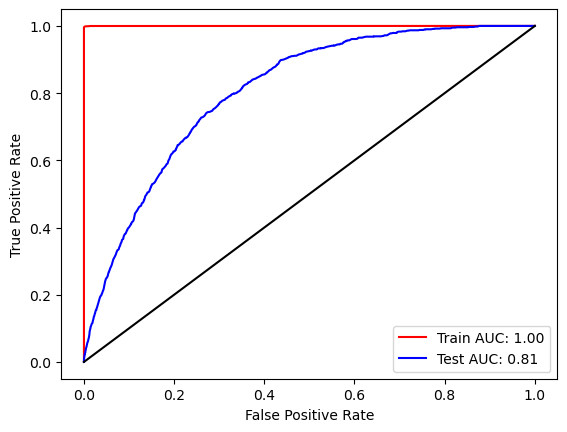

In [52]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

y_train_preds = rf_model_optimized.predict_proba(X_train_resampled)[:,1]
y_test_preds = rf_model_optimized.predict_proba(X_test)[:,1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train_resampled, y_train_preds)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_preds)

auc_train = roc_auc_score(y_train_resampled, y_train_preds)
auc_test = roc_auc_score(y_test, y_test_preds)

plt.plot(fpr_train, tpr_train,'r-', label = 'Train AUC: %.2f'%auc_train)
plt.plot(fpr_test, tpr_test,'b-',label = 'Test AUC: %.2f'%auc_test)
plt.plot([0,1],[0,1],'-k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

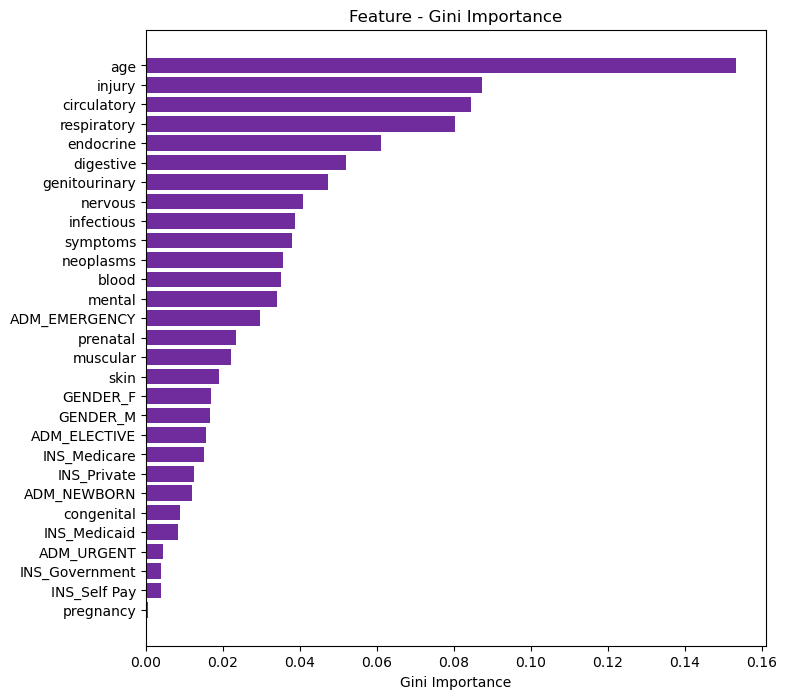

In [54]:
# Retrieve feature importance of the optimized model
importances = rf_model_optimized.feature_importances_
feature_names=X_train_resampled.columns.tolist()
column_names = ['feature','importance']
df_feature_importances = pd.DataFrame(columns=column_names)
df_feature_importances['feature'] = feature_names
df_feature_importances['importance'] = importances
df_features_sorted = df_feature_importances.sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 8))
plt.barh(df_features_sorted['feature'], df_features_sorted['importance'], color='#702b9d')
plt.xlabel('Gini Importance')
plt.title('Feature - Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()